# Statlog Australian Credit Approval - Análisis Pre-ML

## Descripción del Dataset
Dataset de aprobación de crédito australiano (Statlog project). Similar al Credit Approval UCI, contiene información de solicitudes de crédito con atributos anonimizados para proteger confidencialidad.

**Variables:** 14 atributos (6 numéricos, 8 categóricos) + clase binaria
- 690 instancias
- Sin valores faltantes

## Objetivo de Machine Learning
**Clasificación Binaria**: Predecir si la solicitud de crédito es aprobada (1) o rechazada (0)

**Target**: `0` (rechazado) o `1` (aprobado)

**Features potenciales**: 14 atributos anonimizados (mix numérico/categórico)

## PASO 1: Cargar Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Nombres de columnas genéricos
column_names = [f'A{i}' for i in range(1, 15)] + ['target']

# Cargar dataset (espacio como separador)
df = pd.read_csv('australian.dat', names=column_names, sep='\s+', engine='python')

print("✅ Dataset cargado correctamente")

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1870271/1267184622.py:11: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('australian.dat', names=column_names, sep='\s+', engine='python')


✅ Dataset cargado correctamente


## PASO 2: Ver Estructura del Dataset

In [ ]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,target
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [ ]:
df.shape

(690, 15)

In [ ]:
df.dtypes.to_frame(name='dtype')

,dtype
A1,int64
A2,float64
A3,float64
A4,int64
A5,int64
A6,int64
A7,float64
A8,int64
A9,int64
A10,int64


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    int64  
 1   A2      690 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    int64  
 4   A5      690 non-null    int64  
 5   A6      690 non-null    int64  
 6   A7      690 non-null    float64
 7   A8      690 non-null    int64  
 8   A9      690 non-null    int64  
 9   A10     690 non-null    int64  
 10  A11     690 non-null    int64  
 11  A12     690 non-null    int64  
 12  A13     690 non-null    int64  
 13  A14     690 non-null    int64  
 14  target  690 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 81.0 KB


## PASO 3: Valores Faltantes

In [ ]:
# Contar valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ No hay valores faltantes")

✅ No hay valores faltantes


## PASO 4: Gráfico del Target

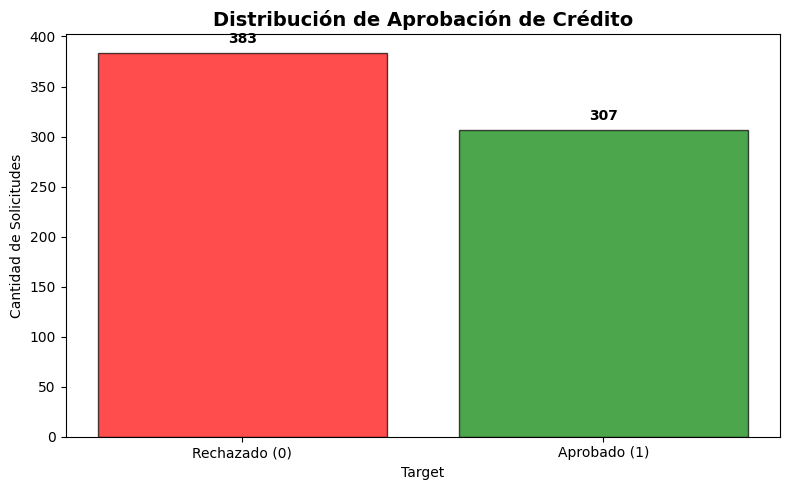


Balance del dataset:
Rechazados (0): 383 (55.5%)
Aprobados (1): 307 (44.5%)


In [ ]:
# Distribución del target
target_counts = df['target'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['Rechazado (0)', 'Aprobado (1)'], target_counts.values, color=['red', 'green'], alpha=0.7, edgecolor='black')
plt.title('Distribución de Aprobación de Crédito', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Solicitudes')
plt.xlabel('Target')

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nBalance del dataset:")
print(f"Rechazados (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Aprobados (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

---
# LIMPIEZA DE DATOS

## Tratamiento de Outliers

In [ ]:
# Estadísticas de variables numéricas
df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,target
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000


In [ ]:
print("✅ No se detectan outliers problemáticos")

✅ No se detectan outliers problemáticos


---
# PREPROCESAMIENTO

## Separar Features y Target

In [ ]:
# Target
y = df['target'].values

# Features (todas numéricas, ya están codificadas)
X = df.drop('target', axis=1).values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (690, 14)
y shape: (690,)


## Train-Test Split Manual (80-20)

In [ ]:
# Configuración
np.random.seed(42)
test_size = 0.2

# Generar índices aleatorios
n_samples = len(X)
indices = np.random.permutation(n_samples)

# Calcular punto de corte
test_size_abs = int(n_samples * test_size)
train_size_abs = n_samples - test_size_abs

# Dividir índices
train_indices = indices[:train_size_abs]
test_indices = indices[train_size_abs:]

# Crear conjuntos
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print(f"✅ Split completado")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"\nDistribución target en Train: {np.bincount(y_train)}")
print(f"Distribución target en Test: {np.bincount(y_test)}")

✅ Split completado
Train: 552 muestras
Test: 138 muestras

Distribución target en Train: [311 241]
Distribución target en Test: [72 66]


## Escalado Manual (StandardScaler)

Fórmula: `x_scaled = (x - mean) / std`

**IMPORTANTE**: Calcular media y desviación estándar SOLO con datos de entrenamiento para evitar data leakage.

In [ ]:
# CONVERTIR A FLOAT ANTES DEL ESCALADO (prevenir errores de tipo)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Calcular media y desviación estándar del TRAIN set
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Evitar división por cero
std_train[std_train == 0] = 1

# Aplicar escalado
X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train

# Convertir a float explícitamente
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

print("✅ Escalado completado")
print(f"\nMedia de X_train_scaled (primeras 5 features): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Desv. Std de X_train_scaled (primeras 5 features): {X_train_scaled.std(axis=0)[:5]}")

✅ Escalado completado

Media de X_train_scaled (primeras 5 features): [-9.37253495e-17  2.08347832e-15  6.76592437e-16  1.48230864e-16
 -7.20035947e-17]
Desv. Std de X_train_scaled (primeras 5 features): [1. 1. 1. 1. 1.]


---
# VALIDACIÓN FINAL

## 1. Verificar Data Leakage

In [ ]:
shared_indices = np.intersect1d(train_indices, test_indices)

if len(shared_indices) == 0:
    print("✅ No hay data leakage (índices únicos en train y test)")
else:
    print(f"⚠️ ALERTA: {len(shared_indices)} índices compartidos detectados")

✅ No hay data leakage (índices únicos en train y test)


## 2. Verificar NaN e Infinitos

In [ ]:
nan_train = np.isnan(X_train_scaled).sum()
nan_test = np.isnan(X_test_scaled).sum()
inf_train = np.isinf(X_train_scaled).sum()
inf_test = np.isinf(X_test_scaled).sum()

print(f"NaN en X_train_scaled: {nan_train}")
print(f"NaN en X_test_scaled: {nan_test}")
print(f"Infinitos en X_train_scaled: {inf_train}")
print(f"Infinitos en X_test_scaled: {inf_test}")

if nan_train == 0 and nan_test == 0 and inf_train == 0 and inf_test == 0:
    print("\n✅ Datos limpios (sin NaN ni infinitos)")
else:
    print("\n⚠️ ALERTA: Hay NaN o infinitos en los datos")

NaN en X_train_scaled: 0
NaN en X_test_scaled: 0
Infinitos en X_train_scaled: 0
Infinitos en X_test_scaled: 0

✅ Datos limpios (sin NaN ni infinitos)


## 3. Comparar Distribuciones Train vs Test

In [ ]:
print("=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===")
print("\nMEDIA:")
print(f"Train: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.mean(axis=0)[:5]}")

print("\nDESVIACIÓN ESTÁNDAR:")
print(f"Train: {X_train_scaled.std(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.std(axis=0)[:5]}")

print("\n✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)")

=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===

MEDIA:
Train: [-9.37253495e-17  2.08347832e-15  6.76592437e-16  1.48230864e-16
 -7.20035947e-17]
Test:  [-0.07018624  0.05372086 -0.119263   -0.0383486  -0.04546138]

DESVIACIÓN ESTÁNDAR:
Train: [1. 1. 1. 1. 1.]
Test:  [1.02513566 1.04407367 0.92365355 1.05230931 1.01878365]

✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)


## Resumen Final

In [ ]:
print("="*60)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*60)
print(f"Dataset original: {df.shape}")
print(f"Features: {X.shape[1]}")
print(f"Train set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"\nTarget (aprobación de crédito):")
print(f"  - Clase 0 (rechazado): {(y==0).sum()} casos")
print(f"  - Clase 1 (aprobado): {(y==1).sum()} casos")
print(f"\n✅ Datos listos para entrenamiento de modelos de clasificación")
print("="*60)

RESUMEN DEL PREPROCESAMIENTO
Dataset original: (690, 15)
Features: 14
Train set: (552, 14)
Test set: (138, 14)

Target (aprobación de crédito):
  - Clase 0 (rechazado): 383 casos
  - Clase 1 (aprobado): 307 casos

✅ Datos listos para entrenamiento de modelos de clasificación
